# Traps and Treasures — Board Analysis

Prototype notebook for exploring board structure and interesting field-set definitions.

**Terminology used throughout:**
- **coordinate** `(c, r)` — column and row *position* (0-indexed integers)
- **labels** of a field — the tuple `(col_label, row_label)` assigned to its column and row

---
## Section 1 — Board Setup

In [1]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from itertools import combinations
from collections import defaultdict

# ── Board parameter (change here to resize everything) ────────────────────────
BOARD_SIZE = 7

In [2]:
def generate_coordinate_labels(size):
    """
    Generate distinct random integers from 0 to 25 for row and column labels.
    Draws 2*size values without replacement and splits them into
    row labels (first half) and column labels (second half).

    Parameters
    ----------
    size : int
        Board side length.  Requires size * 2 <= 26.

    Returns
    -------
    row_labels : list[int]  — one label per row    (r = 0 … size-1)
    col_labels : list[int]  — one label per column (c = 0 … size-1)
    """
    pool = random.sample(range(2, 26), size * 2)
    return pool[:size], pool[size:]

In [3]:
# ── Generate labels (re-run cell to get a fresh random board) ─────────────────
row_labels, col_labels = generate_coordinate_labels(BOARD_SIZE)

# Alternatively, pin specific labels:
# row_labels = [3,  7, 12,  1, 18, 25,  9]
# col_labels = [4, 11,  6, 22,  0, 15, 20]

print(f"Row labels  (r = 0 … {BOARD_SIZE-1}): {row_labels}")
print(f"Col labels  (c = 0 … {BOARD_SIZE-1}): {col_labels}")

Row labels  (r = 0 … 6): [23, 15, 19, 24, 7, 10, 21]
Col labels  (c = 0 … 6): [8, 22, 6, 16, 18, 17, 4]


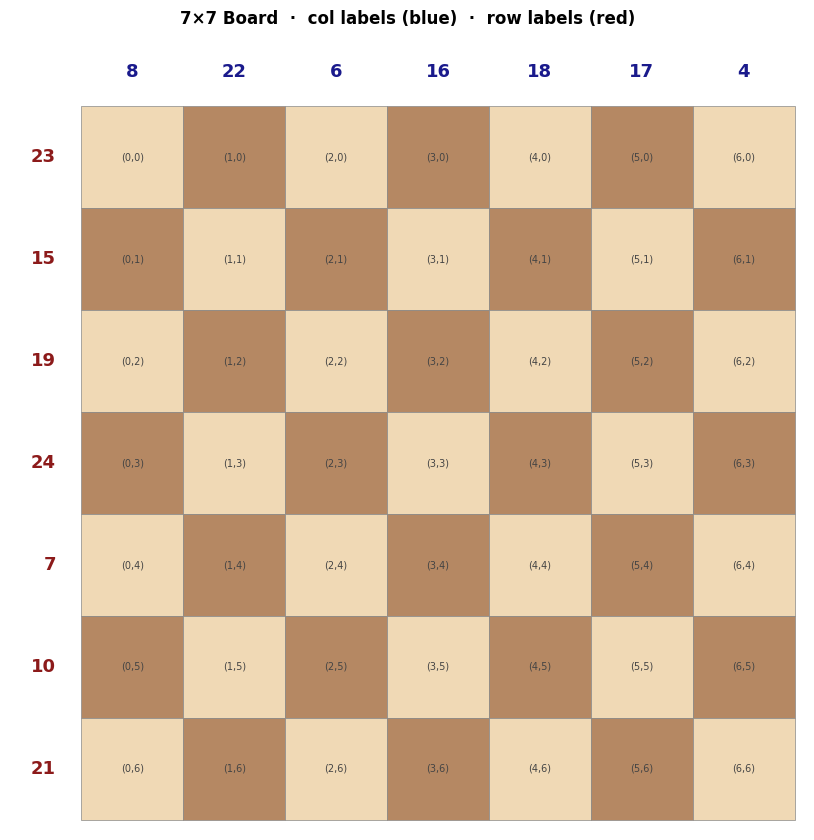

In [4]:
def visualize_board(size, col_labels, row_labels, highlight=None, title="Board"):
    """
    Draw a chess-like board with row / column labels.

    Layout
    ------
    - r = 0 is the top row, r = size-1 is the bottom row.
    - c = 0 is the leftmost column.
    - Column labels (blue) are shown above the board.
    - Row labels (red) are shown to the left of the board.
    - Each cell shows its coordinate (c, r) in small grey text.

    Parameters
    ----------
    highlight : set of (c, r) tuples to colour green, optional
    """
    hl = set(highlight) if highlight else set()
    fig, ax = plt.subplots(figsize=(size + 1.5, size + 1.5))

    for r in range(size):
        svg_y = size - 1 - r            # flip so r=0 appears at the top
        for c in range(size):
            light  = (c + r) % 2 == 0
            base   = '#F0D9B5' if light else '#B58863'
            color  = '#6abf69' if (c, r) in hl else base
            ax.add_patch(patches.Rectangle(
                (c, svg_y), 1, 1,
                linewidth=0.5, edgecolor='#888888', facecolor=color
            ))
            ax.text(c + 0.5, svg_y + 0.5, f'({c},{r})',
                    ha='center', va='center',
                    fontsize=max(5, 9 - size // 3), color='#444444')

    # Column labels — above the board
    for c in range(size):
        ax.text(c + 0.5, size + 0.25, str(col_labels[c]),
                ha='center', va='bottom',
                fontsize=13, fontweight='bold', color='#1a1a8c')

    # Row labels — left of the board
    for r in range(size):
        ax.text(-0.25, size - 1 - r + 0.5, str(row_labels[r]),
                ha='right', va='center',
                fontsize=13, fontweight='bold', color='#8c1a1a')

    ax.set_xlim(-0.7, size + 0.1)
    ax.set_ylim(-0.1, size + 0.7)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    plt.tight_layout()
    plt.show()


visualize_board(
    BOARD_SIZE, col_labels, row_labels,
    title=f"{BOARD_SIZE}×{BOARD_SIZE} Board  ·  col labels (blue)  ·  row labels (red)"
)

---
## Section 2 — Field-Set Functions

Each function returns a **set of `(c, r)` coordinate tuples** — the fields satisfying its condition.

| Function | Condition |
|---|---|
| `get_inbetween_fields` | Fields lying strictly between two fields that share the same sum or product of their *labels* |
| `get_center_fields` | The middle field(s) in terms of label value ordering (median row label × median col label) |
| `get_label_plus_coord_fields` | Fields where one axis's label plus its coordinate position equals the other axis's label |
| `get_sum_min_fields` | Fields whose label-sum (col label + row label) is smaller or larger than all orthogonal neighbors |
| `get_digits_lines_fields` | Fields where both labels consist only of the digits 1, 4, 7 |
| `get_local_mins_fields` | Dead-ends of all strictly-descending label-sum paths starting from the center |
| `get_divisible_sum_fields` | Fields whose label-sum is divisible by a given number |
| `get_diff_diags_fields` | Diagonal neighbor pairs where \|Δcol_label\| == \|Δrow_label\| |

In [5]:
def get_inbetween_fields(size, col_labels, row_labels, mode='sum'):
    """
    Fields lying *strictly between* two fields that share the same
    sum (mode='sum') or product (mode='product') of their labels
    (col_labels[c] + row_labels[r]  or  col_labels[c] * row_labels[r]).

    'Between' is defined in the chess sense: field B is between A and C when
    A, B, C are collinear (same row, same column, or same diagonal) and B sits
    strictly inside the segment A–C.

    Notes
    -----
    - The two endpoint fields themselves are *not* included in the result.
    - Pairs that are not collinear contribute no intermediate fields.
    """
    def label_value(c, r):
        return (col_labels[c] + row_labels[r]) if mode == 'sum' else (col_labels[c] * row_labels[r])

    # Group field coordinates by their label sum / product
    groups = defaultdict(list)
    for r in range(size):
        for c in range(size):
            groups[label_value(c, r)].append((c, r))

    between = set()
    for fields in groups.values():
        if len(fields) < 2:
            continue
        for (c1, r1), (c2, r2) in combinations(fields, 2):
            dc, dr = c2 - c1, r2 - r1
            # Determine unit step if the pair is collinear
            if dc == 0 and dr != 0:               # same column
                sc, sr = 0, (1 if dr > 0 else -1)
            elif dr == 0 and dc != 0:             # same row
                sc, sr = (1 if dc > 0 else -1), 0
            elif abs(dc) == abs(dr):              # diagonal
                sc = 1 if dc > 0 else -1
                sr = 1 if dr > 0 else -1
            else:
                continue  # not collinear — no 'between' fields

            # Walk strictly between the two endpoints
            c, r = c1 + sc, r1 + sr
            while (c, r) != (c2, r2):
                between.add((c, r))
                c += sc
                r += sr

    return between

In [6]:
def get_center_fields(size, col_labels, row_labels):
    """
    The middle field(s) in terms of label value ordering.

    For each axis the labels are sorted and the median value(s) identified.
    Returns all fields at the intersection of a median-row and a median-column.

    Odd  size → 1 median per axis → 1 center field
    Even size → 2 medians per axis → up to 4 center fields
    """
    def median_indices(labels):
        """Indices of the median label value(s) in the original list."""
        n = len(labels)
        sorted_vals = sorted(labels)
        if n % 2 == 1:
            med = sorted_vals[n // 2]
            return [i for i, v in enumerate(labels) if v == med]
        else:
            lo, hi = sorted_vals[n // 2 - 1], sorted_vals[n // 2]
            return [i for i, v in enumerate(labels) if v in (lo, hi)]

    row_idxs = median_indices(row_labels)
    col_idxs = median_indices(col_labels)
    return {(c, r) for r in row_idxs for c in col_idxs}

In [7]:
def get_label_plus_coord_fields(size, col_labels, row_labels):
    """
    Fields (c, r) where one axis's label summed with its coordinate position
    equals the label of the other axis:

        col_labels[c] + c  ==  row_labels[r]   (col label + col position = row label)
        OR
        row_labels[r] + r  ==  col_labels[c]   (row label + row position = col label)

    Both conditions are checked independently; the result is their union.
    """
    result = set()
    for r in range(size):
        for c in range(size):
            if col_labels[c] + c == row_labels[r]:
                result.add((c, r))
            if row_labels[r] + r == col_labels[c]:
                result.add((c, r))
    return result

In [8]:
def get_sum_min_fields(size, col_labels, row_labels, mode='min'):
    """
    Fields whose label-sum (col_labels[c] + row_labels[r]) is strictly
    smaller (mode='min') or strictly larger (mode='max') than the label-sum
    of every orthogonal neighbor (up / down / left / right).

    Boundary fields are compared only against their existing neighbors.
    """
    _DIRS = [(0, -1), (0, 1), (-1, 0), (1, 0)]   # up, down, left, right

    def lsum(c, r):
        return col_labels[c] + row_labels[r]

    result = set()
    for r in range(size):
        for c in range(size):
            s = lsum(c, r)
            nbr = [
                lsum(c + dc, r + dr)
                for dc, dr in _DIRS
                if 0 <= c + dc < size and 0 <= r + dr < size
            ]
            if mode == 'min' and all(s < n for n in nbr):
                result.add((c, r))
            elif mode == 'max' and all(s > n for n in nbr):
                result.add((c, r))
    return result

In [9]:
def get_digits_lines_fields(size, col_labels, row_labels):
    """
    Fields where *both* labels consist exclusively of the digits 1, 4, and 7.

    These are exactly the digits that are drawn with straight lines only
    (no curves): 1 — vertical stroke, 4 — two verticals + horizontal,
    7 — horizontal + diagonal stroke.

    Examples: 1, 4, 7, 11, 14, 17, 41, 44, 47, 71, 74, 77, 111, …
    """
    # 1, 4, 7 are exactly the digits that consist of straight lines only
    STRAIGHT = set('147')

    def is_straight_line_number(n):
        return all(d in STRAIGHT for d in str(abs(n)))

    result = set()
    for r in range(size):
        for c in range(size):
            if is_straight_line_number(col_labels[c]) and is_straight_line_number(row_labels[r]):
                result.add((c, r))
    return result

In [10]:
def get_local_mins_fields(size, col_labels, row_labels):
    """
    Starting from the center field(s), follow all paths that move to an
    orthogonal neighbor with a strictly smaller label-sum
    (col_labels[c] + row_labels[r]).  Return the dead-end fields reached
    at the end of every such path — i.e. fields where no orthogonal neighbor
    has a smaller label-sum (local minima reachable from the center).

    Notes
    -----
    - The center field itself is returned if it is already a local minimum.
    - Each reachable field is processed only once (visited-set BFS).
    """
    _DIRS = [(0, -1), (0, 1), (-1, 0), (1, 0)]

    def lsum(c, r):
        return col_labels[c] + row_labels[r]

    start = get_center_fields(size, col_labels, row_labels)
    visited  = set()
    endpoints = set()
    stack = list(start)

    while stack:
        c, r = stack.pop()
        if (c, r) in visited:
            continue
        visited.add((c, r))
        s = lsum(c, r)
        can_move = False
        for dc, dr in _DIRS:
            nc, nr = c + dc, r + dr
            if 0 <= nc < size and 0 <= nr < size and lsum(nc, nr) < s:
                can_move = True
                stack.append((nc, nr))
        if not can_move:
            endpoints.add((c, r))

    return endpoints

In [11]:
def get_divisible_sum_fields(size, col_labels, row_labels, divisor=5):
    """
    Fields where the label-sum (col_labels[c] + row_labels[r]) is exactly
    divisible by `divisor`.

    Parameters
    ----------
    divisor : int
        The number the label-sum must be divisible by (default 5).
    """
    result = set()
    for r in range(size):
        for c in range(size):
            if (col_labels[c] + row_labels[r]) % divisor == 0:
                result.add((c, r))
    return result

In [12]:
def get_diff_diags_fields(size, col_labels, row_labels, return_fields='both'):
    """
    Diagonal neighbor pairs where the absolute difference in column labels
    equals the absolute difference in row labels:

        |col_labels[c2] - col_labels[c1]|  ==  |row_labels[r2] - row_labels[r1]|

    Each qualifying pair contributes field(s) to the result according to
    `return_fields`:

        'both'         — both fields of the pair
        'left'         — the field with the smaller column coordinate
        'upper'        — the field with the smaller row coordinate (r=0 is top)
        'larger_label' — the field with the larger label-sum
                         (col_label + row_label); ties include both

    Notes
    -----
    Every diagonal edge is considered exactly once (c2 = c1 + 1 always).
    """
    result = set()

    def handle_pair(c1, r1, c2, r2):
        if abs(col_labels[c2] - col_labels[c1]) != abs(row_labels[r2] - row_labels[r1]):
            return
        if return_fields == 'both':
            result.add((c1, r1))
            result.add((c2, r2))
        elif return_fields == 'left':
            result.add((c1, r1))          # c1 < c2 always
        elif return_fields == 'upper':
            result.add((c1, r1) if r1 <= r2 else (c2, r2))
        elif return_fields == 'larger_label':
            s1 = col_labels[c1] + row_labels[r1]
            s2 = col_labels[c2] + row_labels[r2]
            if s1 >= s2:
                result.add((c1, r1))
            if s2 >= s1:
                result.add((c2, r2))

    for r in range(size):
        for c in range(size - 1):
            if r + 1 < size:
                handle_pair(c, r, c + 1, r + 1)   # down-right diagonal
            if r - 1 >= 0:
                handle_pair(c, r, c + 1, r - 1)   # up-right diagonal

    return result

### Demo — run all functions and visualise results

inbetween (sum)  — 8 fields: [(1, 2), (2, 3), (2, 4), (3, 3), (4, 2), (4, 4), (5, 4), (5, 5)]


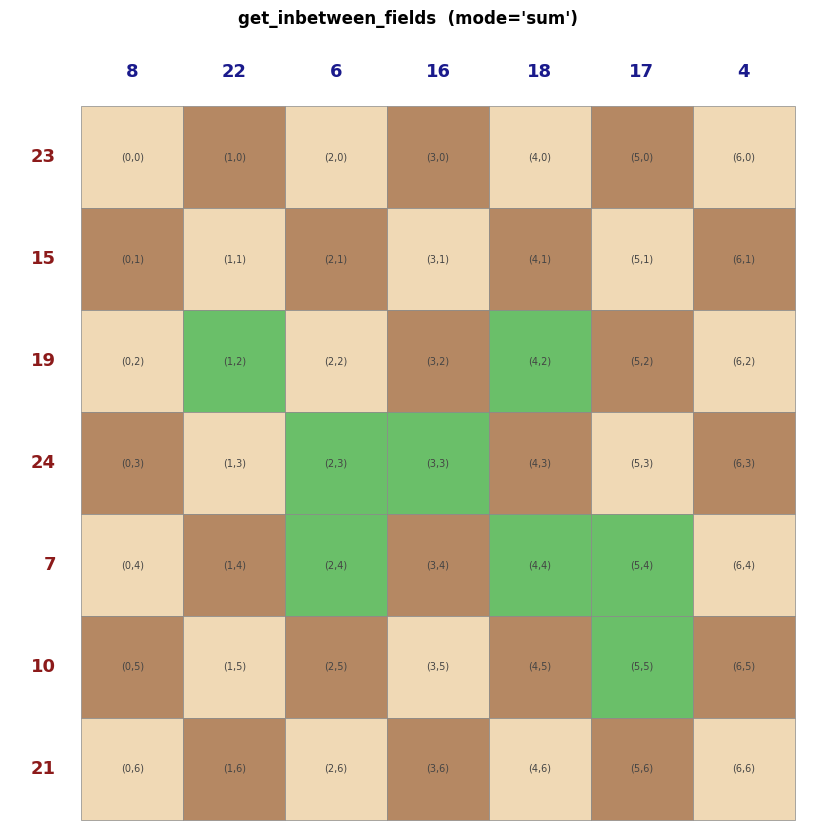

In [13]:
# ── inbetween (label sum) ─────────────────────────────────────────────────────
ib_sum = get_inbetween_fields(BOARD_SIZE, col_labels, row_labels, mode='sum')
print(f"inbetween (sum)  — {len(ib_sum)} fields: {sorted(ib_sum)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=ib_sum,
                title="get_inbetween_fields  (mode='sum')")

inbetween (product)  — 4 fields: [(3, 4), (3, 5), (4, 3), (5, 2)]


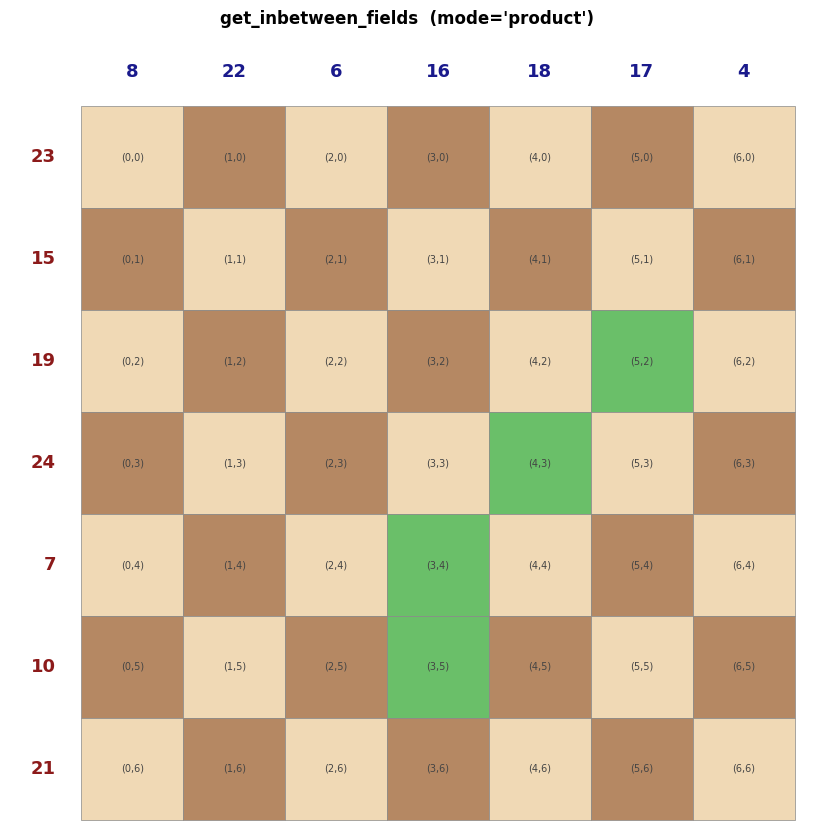

In [14]:
# ── inbetween (label product) ─────────────────────────────────────────────────
ib_prod = get_inbetween_fields(BOARD_SIZE, col_labels, row_labels, mode='product')
print(f"inbetween (product)  — {len(ib_prod)} fields: {sorted(ib_prod)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=ib_prod,
                title="get_inbetween_fields  (mode='product')")

digits_lines  — 2 field(s): [(5, 4), (6, 4)]
  (straight-line col labels: [17, 4])
  (straight-line row labels: [7])


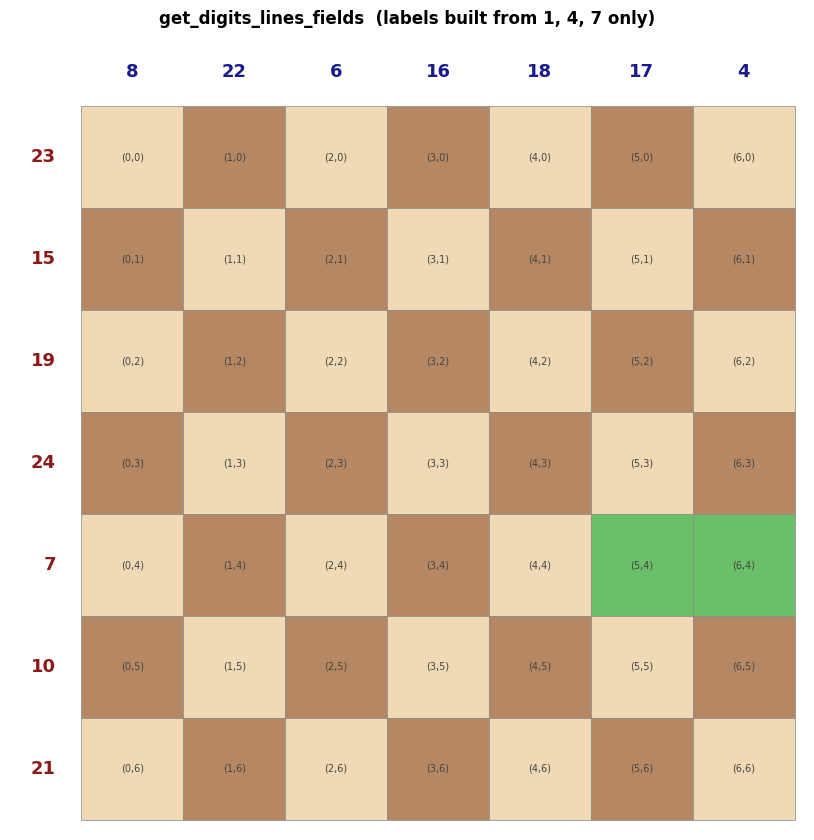

In [15]:
# ── digits_lines ──────────────────────────────────────────────────────────────
dl = get_digits_lines_fields(BOARD_SIZE, col_labels, row_labels)
print(f"digits_lines  — {len(dl)} field(s): {sorted(dl)}")
print(f"  (straight-line col labels: {[v for v in col_labels if all(d in '147' for d in str(v))]})")
print(f"  (straight-line row labels: {[v for v in row_labels if all(d in '147' for d in str(v))]})")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=dl,
                title="get_digits_lines_fields  (labels built from 1, 4, 7 only)")

center field(s): [(3, 2)]
local_mins  — 1 endpoint(s): [(2, 1)]


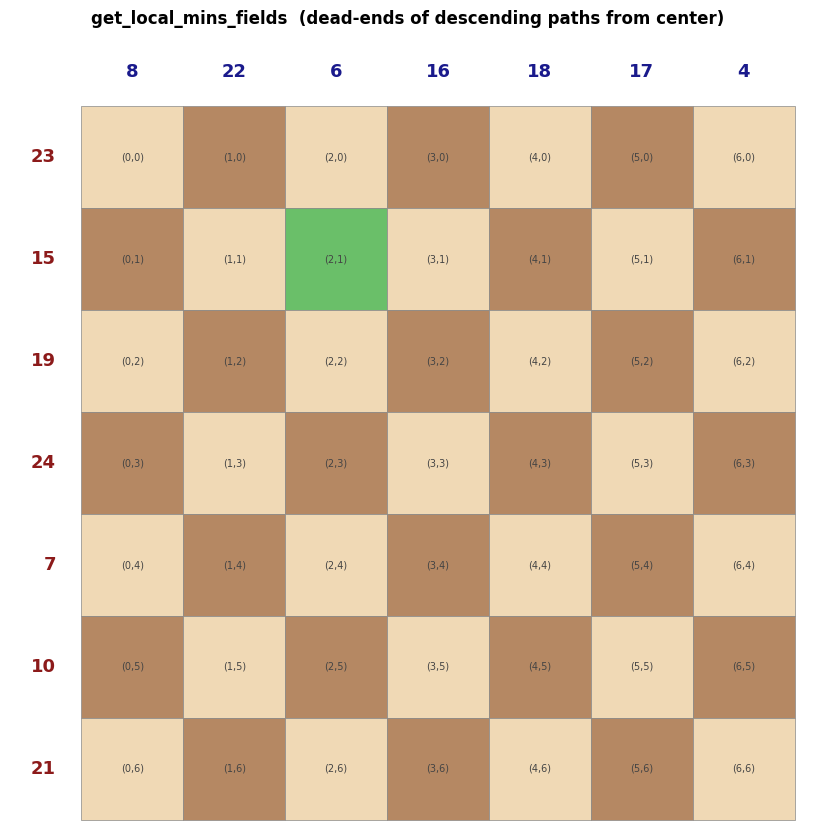

In [16]:
# ── local_mins ────────────────────────────────────────────────────────────────
center = get_center_fields(BOARD_SIZE, col_labels, row_labels)
lm = get_local_mins_fields(BOARD_SIZE, col_labels, row_labels)
print(f"center field(s): {sorted(center)}")
print(f"local_mins  — {len(lm)} endpoint(s): {sorted(lm)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=lm,
                title="get_local_mins_fields  (dead-ends of descending paths from center)")

divisible_sum (÷5)  — 9 field(s): [(0, 4), (1, 0), (2, 2), (2, 3), (3, 2), (3, 3), (4, 4), (5, 0), (6, 6)]


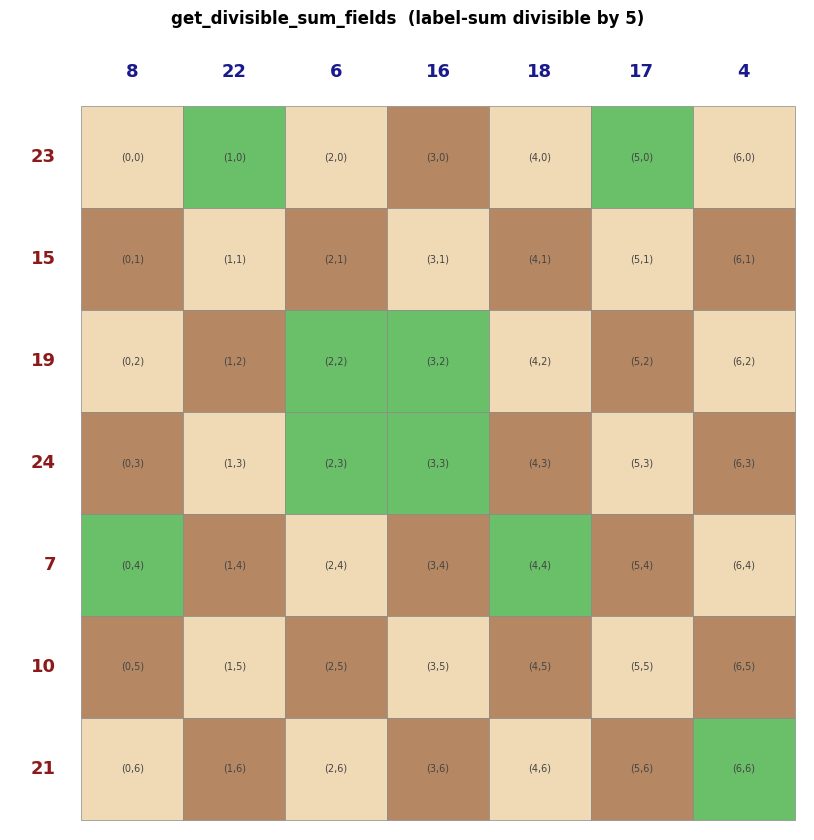

In [17]:
# ── divisible_sum ─────────────────────────────────────────────────────────────
ds = get_divisible_sum_fields(BOARD_SIZE, col_labels, row_labels, divisor=5)
print(f"divisible_sum (÷5)  — {len(ds)} field(s): {sorted(ds)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=ds,
                title="get_divisible_sum_fields  (label-sum divisible by 5)")

diff_diags (both          )  — 0 field(s): []


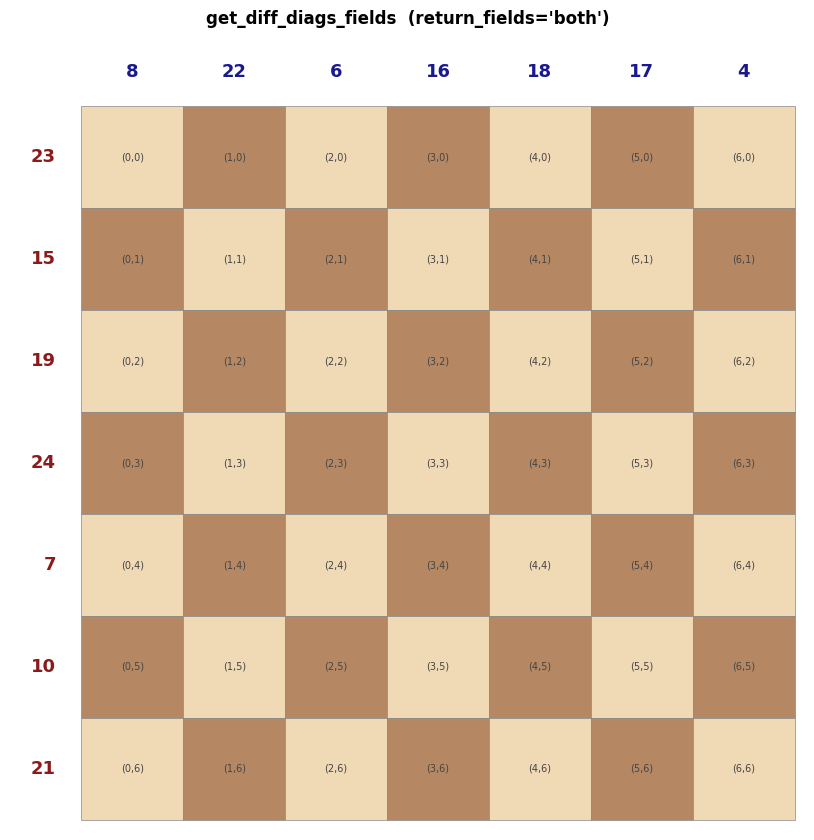

diff_diags (left          )  — 0 field(s): []


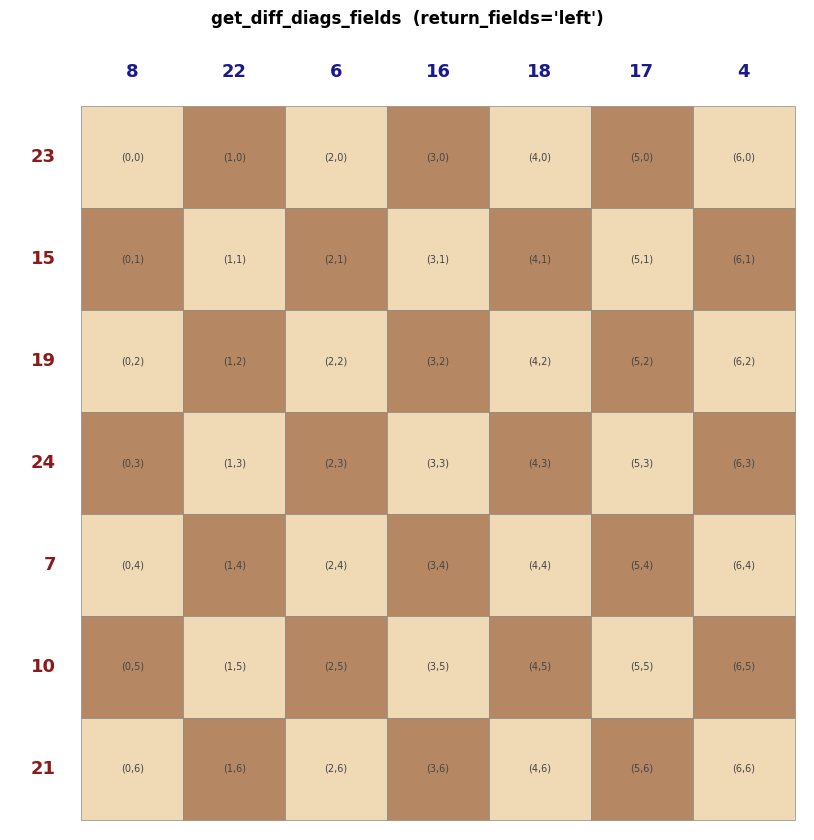

diff_diags (upper         )  — 0 field(s): []


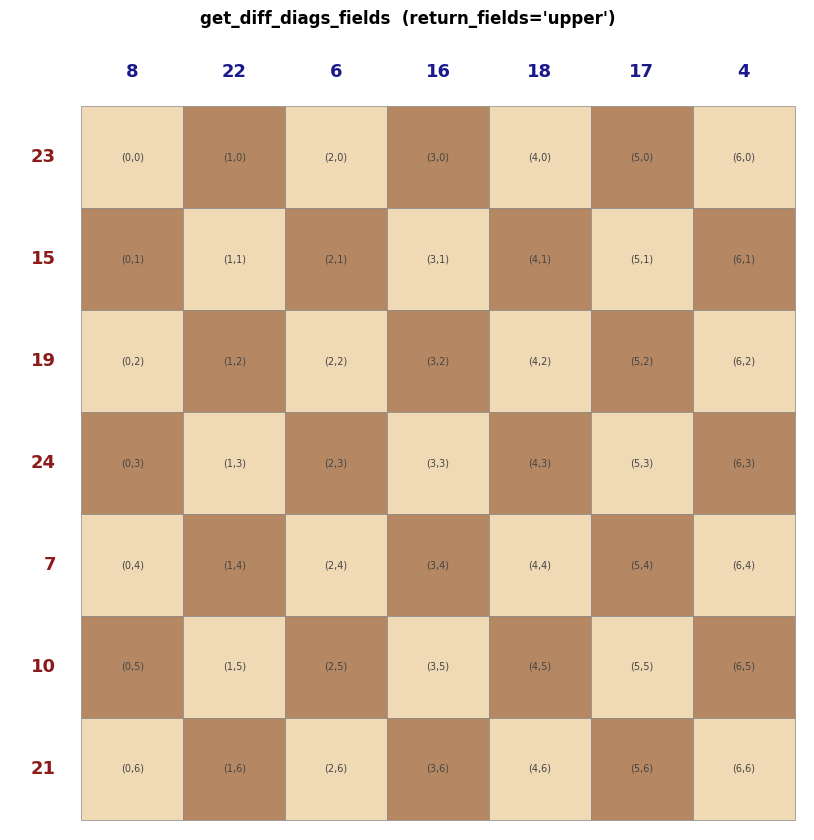

diff_diags (larger_label  )  — 0 field(s): []


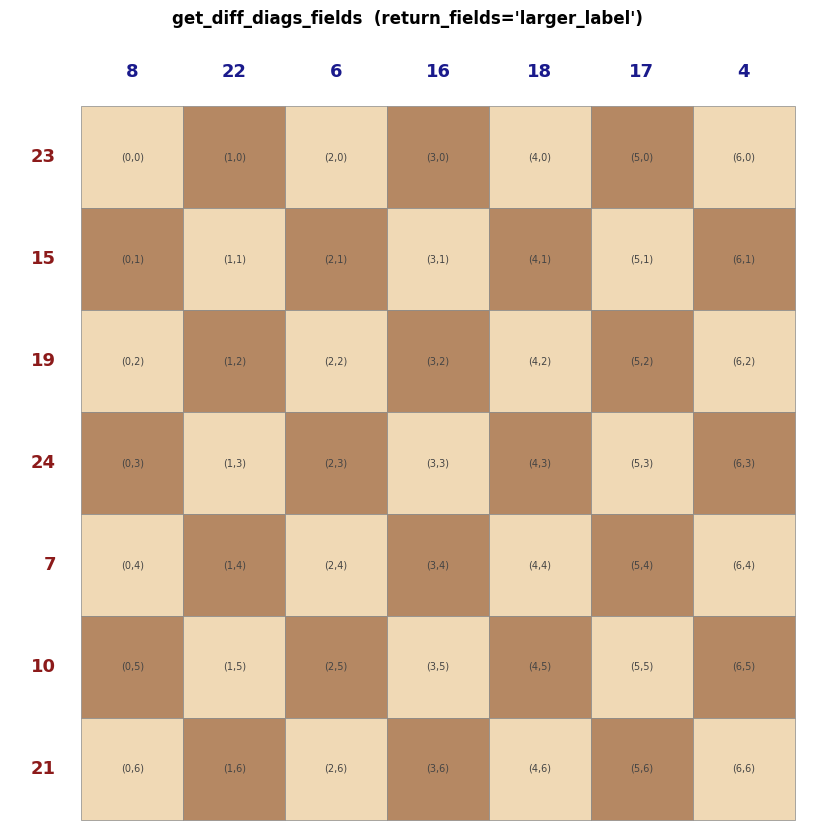

In [18]:
# ── diff_diags ────────────────────────────────────────────────────────────────
for mode in ('both', 'left', 'upper', 'larger_label'):
    dd = get_diff_diags_fields(BOARD_SIZE, col_labels, row_labels, return_fields=mode)
    print(f"diff_diags ({mode:14s})  — {len(dd)} field(s): {sorted(dd)}")
    visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=dd,
                    title=f"get_diff_diags_fields  (return_fields='{mode}')")

---
## Section 3 — Statistics over Random Boards

For a fixed board size, sample **500 randomly labelled boards** and collect three metrics
per function variant per board:

| Metric | Description |
|---|---|
| **field count** | number of fields returned |
| **ortho neighbors** | unordered neighbor pairs within the returned set (orthogonal only) |
| **all neighbors** | unordered neighbor pairs within the returned set (orthogonal + diagonal) |

Summary statistics (min, Q25, median, mean, Q75, max) are shown per function,
followed by a **heatmap** of how often each cell was included across the 500 samples.

In [19]:
import numpy as np
import pandas as pd

N_SAMPLES = 500

# ── All function variants to analyse ──────────────────────────────────────────
# Each entry: (display_name, callable(size, col_labels, row_labels) -> set of (c,r))
FUNC_VARIANTS = [
    ('inbetween  sum',     lambda s,cl,rl: get_inbetween_fields(s, cl, rl, mode='sum')),
    ('inbetween  product', lambda s,cl,rl: get_inbetween_fields(s, cl, rl, mode='product')),
    ('center',             lambda s,cl,rl: get_center_fields(s, cl, rl)),
    ('label_plus_coord',   lambda s,cl,rl: get_label_plus_coord_fields(s, cl, rl)),
    ('sum_min  min',       lambda s,cl,rl: get_sum_min_fields(s, cl, rl, mode='min')),
    ('sum_min  max',       lambda s,cl,rl: get_sum_min_fields(s, cl, rl, mode='max')),
    ('digits_lines',       lambda s,cl,rl: get_digits_lines_fields(s, cl, rl)),
    ('local_mins',         lambda s,cl,rl: get_local_mins_fields(s, cl, rl)),
    ('divisible_sum ÷5',   lambda s,cl,rl: get_divisible_sum_fields(s, cl, rl, divisor=5)),
    ('diff_diags  both',   lambda s,cl,rl: get_diff_diags_fields(s, cl, rl, return_fields='both')),
]

# ── Neighbor-relation counter ──────────────────────────────────────────────────
def count_neighbor_relations(fields, include_diagonal=False):
    """
    Count unordered neighbor pairs within a set of fields.
    Iterates only 'forward' directions so each pair is counted once.
      orthogonal only  : (0,+1), (+1,0)
      incl. diagonal   : (0,+1), (+1,-1), (+1,0), (+1,+1)
    """
    fs = set(fields)
    fwd = [(0,1),(1,-1),(1,0),(1,1)] if include_diagonal else [(0,1),(1,0)]
    return sum(1 for (c,r) in fs for dc,dr in fwd if (c+dc, r+dr) in fs)

# ── Simulation ─────────────────────────────────────────────────────────────────
size     = BOARD_SIZE
n_funcs  = len(FUNC_VARIANTS)

field_counts = [[] for _ in range(n_funcs)]
ortho_nbrs   = [[] for _ in range(n_funcs)]
all_nbrs     = [[] for _ in range(n_funcs)]
heatmaps     = [np.zeros((size, size), dtype=int) for _ in range(n_funcs)]

for _ in range(N_SAMPLES):
    row_lbl, col_lbl = generate_coordinate_labels(size)
    for i, (_, fn) in enumerate(FUNC_VARIANTS):
        fields = fn(size, col_lbl, row_lbl)
        field_counts[i].append(len(fields))
        ortho_nbrs[i].append(count_neighbor_relations(fields, include_diagonal=False))
        all_nbrs[i].append(count_neighbor_relations(fields, include_diagonal=True))
        for c, r in fields:
            heatmaps[i][r, c] += 1

field_counts = [np.array(v) for v in field_counts]
ortho_nbrs   = [np.array(v) for v in ortho_nbrs]
all_nbrs     = [np.array(v) for v in all_nbrs]

print(f"Done: {N_SAMPLES} boards × {n_funcs} function variants on a {size}×{size} board.")

Done: 500 boards × 10 function variants on a 7×7 board.


In [20]:
# ── Summary statistics ────────────────────────────────────────────────────────
def make_stats_df(arrays, names):
    rows = []
    for name, arr in zip(names, arrays):
        rows.append({
            'min':    int(arr.min()),
            'Q25':    round(float(np.percentile(arr, 25)), 2),
            'median': round(float(np.median(arr)), 2),
            'mean':   round(float(arr.mean()), 2),
            'Q75':    round(float(np.percentile(arr, 75)), 2),
            'max':    int(arr.max()),
        })
    return pd.DataFrame(rows, index=names)

names = [name for name, _ in FUNC_VARIANTS]

print(f"{'═'*60}")
print(f"  Field count  (N={N_SAMPLES} samples, board {size}×{size})")
print(f"{'═'*60}")
display(make_stats_df(field_counts, names))

print(f"\n{'═'*60}")
print(f"  Orthogonal neighbor relations within returned fields")
print(f"{'═'*60}")
display(make_stats_df(ortho_nbrs, names))

print(f"\n{'═'*60}")
print(f"  All neighbor relations (orthogonal + diagonal)")
print(f"{'═'*60}")
display(make_stats_df(all_nbrs, names))

════════════════════════════════════════════════════════════
  Field count  (N=500 samples, board 7×7)
════════════════════════════════════════════════════════════


,min,Q25,median,mean,Q75,max
inbetween sum,0,3.0,6.0,5.80,8.0,18
inbetween product,0,0.0,0.0,0.66,1.0,9
center,1,1.0,1.0,1.00,1.0,1
label_plus_coord,0,2.0,3.0,3.19,4.0,8
sum_min min,2,6.0,6.0,7.09,9.0,16
sum_min max,2,6.0,6.0,7.03,9.0,16
digits_lines,0,0.0,2.0,1.83,3.0,6
local_mins,1,1.0,1.0,1.33,2.0,4
divisible_sum ÷5,3,9.0,10.0,9.87,11.0,18
diff_diags both,0,4.0,8.0,8.17,12.0,31



════════════════════════════════════════════════════════════
  Orthogonal neighbor relations within returned fields
════════════════════════════════════════════════════════════


,min,Q25,median,mean,Q75,max
inbetween sum,0,0.0,1.0,2.43,4.0,21
inbetween product,0,0.0,0.0,0.10,0.0,7
center,0,0.0,0.0,0.00,0.0,0
label_plus_coord,0,0.0,0.0,0.33,1.0,4
sum_min min,0,0.0,0.0,0.00,0.0,0
sum_min max,0,0.0,0.0,0.00,0.0,0
digits_lines,0,0.0,0.0,0.39,0.0,5
local_mins,0,0.0,0.0,0.00,0.0,0
divisible_sum ÷5,0,1.0,2.0,2.74,4.0,14
diff_diags both,0,4.0,8.0,9.04,13.0,45



════════════════════════════════════════════════════════════
  All neighbor relations (orthogonal + diagonal)
════════════════════════════════════════════════════════════


,min,Q25,median,mean,Q75,max
inbetween sum,0,2.0,5.0,6.45,10.0,39
inbetween product,0,0.0,0.0,0.42,0.0,13
center,0,0.0,0.0,0.00,0.0,0
label_plus_coord,0,0.0,0.0,0.68,1.0,6
sum_min min,0,0.0,0.0,0.00,0.0,0
sum_min max,0,0.0,0.0,0.00,0.0,0
digits_lines,0,0.0,0.0,0.42,0.0,7
local_mins,0,0.0,0.0,0.00,0.0,0
divisible_sum ÷5,0,3.0,5.0,5.66,7.0,21
diff_diags both,0,6.0,12.0,14.63,21.0,83


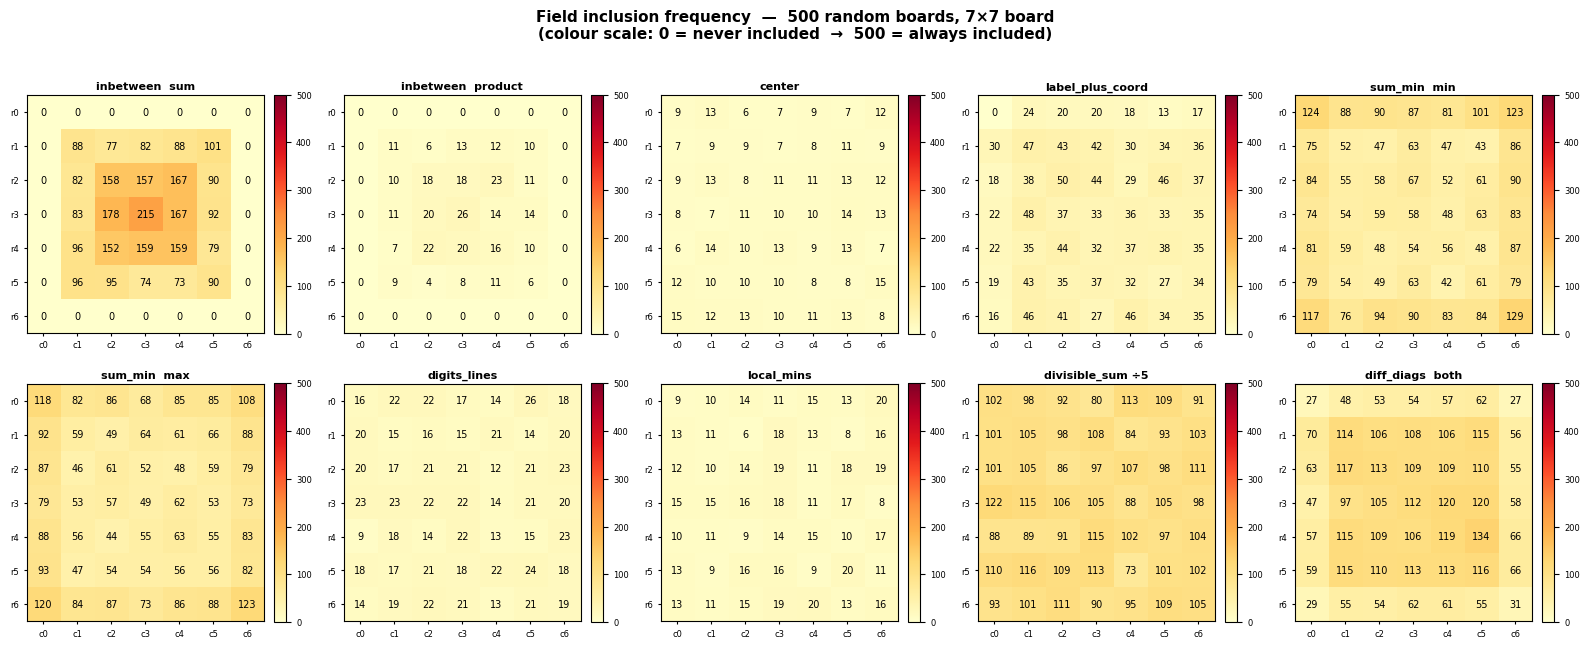

In [21]:
# ── Heatmaps ──────────────────────────────────────────────────────────────────
# Each cell shows how many of the N_SAMPLES boards included that field.

n_cols  = 5
n_rows  = (n_funcs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 3.2, n_rows * 3.2))
axes = np.array(axes).flatten()

for i, (name, _) in enumerate(FUNC_VARIANTS):
    ax  = axes[i]
    hm  = heatmaps[i]
    vmax = N_SAMPLES

    im = ax.imshow(hm, cmap='YlOrRd', vmin=0, vmax=vmax,
                   origin='upper', aspect='equal',
                   interpolation='nearest')

    # Annotate each cell with the raw count
    threshold = vmax * 0.55
    for r in range(size):
        for c in range(size):
            val = hm[r, c]
            ax.text(c, r, str(val),
                    ha='center', va='center',
                    fontsize=max(4, 9 - size // 3),
                    color='white' if val > threshold else 'black')

    ax.set_title(name, fontsize=8, fontweight='bold', pad=4)
    ax.set_xticks(np.arange(size))
    ax.set_yticks(np.arange(size))
    ax.set_xticklabels([f'c{c}' for c in range(size)], fontsize=6)
    ax.set_yticklabels([f'r{r}' for r in range(size)], fontsize=6)
    ax.tick_params(length=2)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(labelsize=6)

# Hide any unused subplot slots
for j in range(n_funcs, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"Field inclusion frequency  —  {N_SAMPLES} random boards, {size}×{size} board\n"
    f"(colour scale: 0 = never included  →  {N_SAMPLES} = always included)",
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

center  — 1 field(s): [(3, 2)]


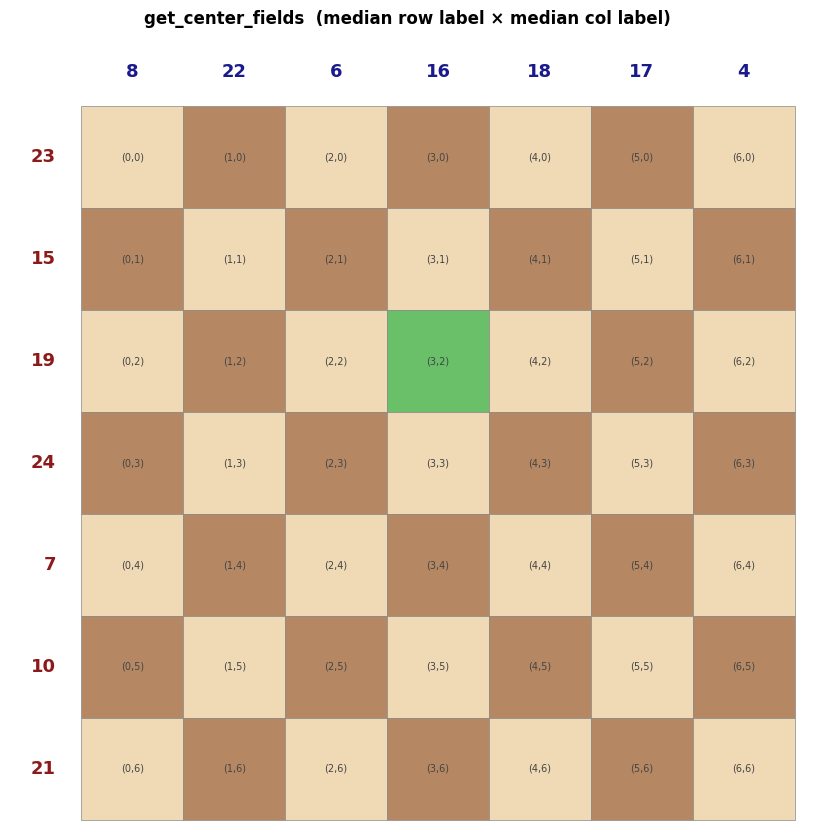

In [22]:
# ── center ────────────────────────────────────────────────────────────────────
cf = get_center_fields(BOARD_SIZE, col_labels, row_labels)
print(f"center  — {len(cf)} field(s): {sorted(cf)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=cf,
                title="get_center_fields  (median row label × median col label)")

label_plus_coord  — 4 field(s): [(1, 0), (3, 1), (3, 2), (6, 5)]


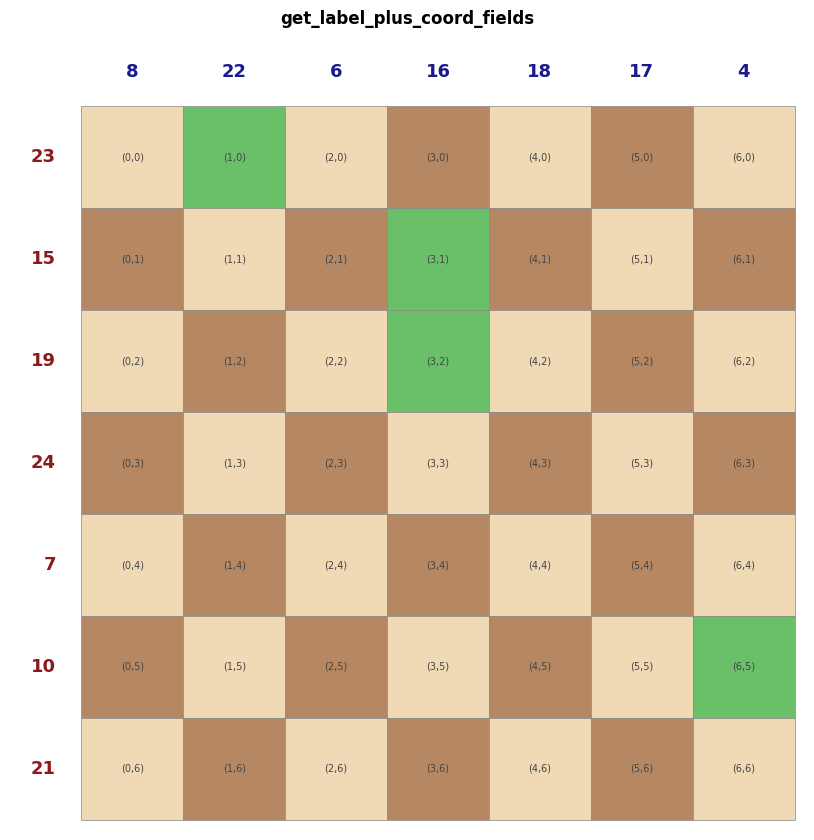

In [23]:
# ── label + coord ─────────────────────────────────────────────────────────────
lpc = get_label_plus_coord_fields(BOARD_SIZE, col_labels, row_labels)
print(f"label_plus_coord  — {len(lpc)} field(s): {sorted(lpc)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=lpc,
                title="get_label_plus_coord_fields")

sum_min (min)  — 6 field(s): [(0, 1), (0, 4), (2, 1), (2, 4), (6, 1), (6, 4)]


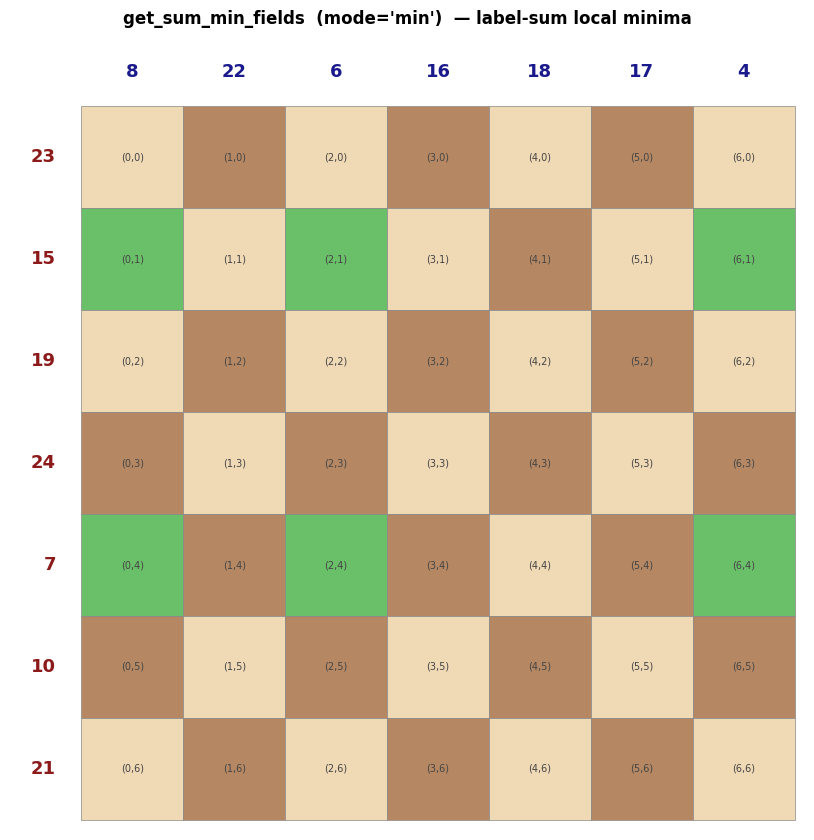

In [24]:
# ── label-sum local minima ────────────────────────────────────────────────────
sm_min = get_sum_min_fields(BOARD_SIZE, col_labels, row_labels, mode='min')
print(f"sum_min (min)  — {len(sm_min)} field(s): {sorted(sm_min)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=sm_min,
                title="get_sum_min_fields  (mode='min')  — label-sum local minima")

sum_min (max)  — 6 field(s): [(1, 0), (1, 3), (1, 6), (4, 0), (4, 3), (4, 6)]


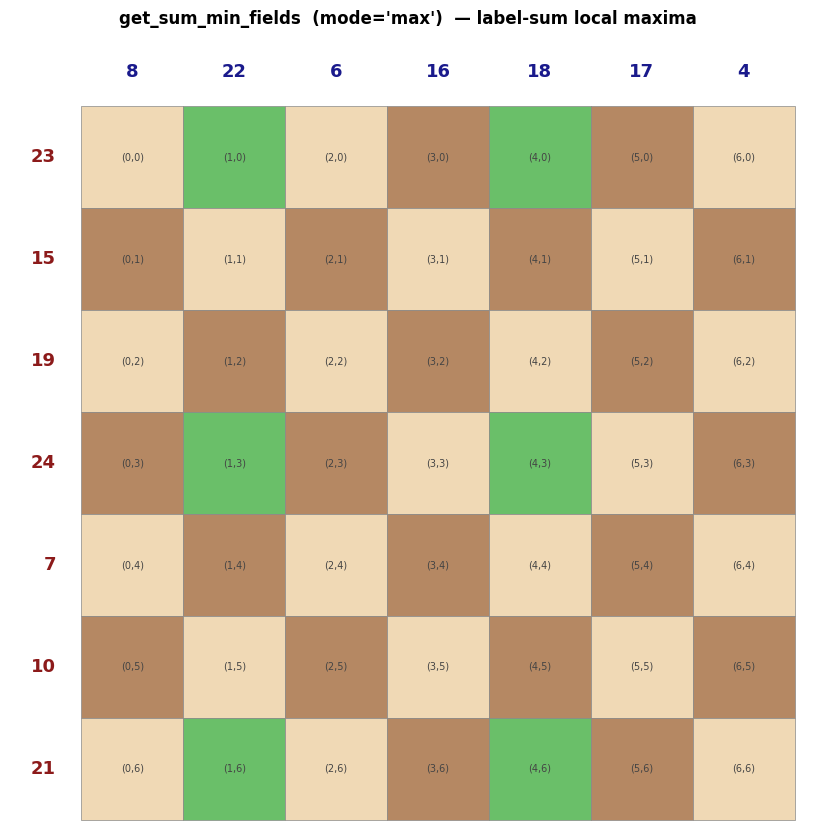

In [25]:
# ── label-sum local maxima ────────────────────────────────────────────────────
sm_max = get_sum_min_fields(BOARD_SIZE, col_labels, row_labels, mode='max')
print(f"sum_min (max)  — {len(sm_max)} field(s): {sorted(sm_max)}")
visualize_board(BOARD_SIZE, col_labels, row_labels, highlight=sm_max,
                title="get_sum_min_fields  (mode='max')  — label-sum local maxima")